In [28]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Arc
from matplotlib.lines import Line2D

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [108]:
def add_dt_text(ax, dt):
    ax.text(0.01, 0.01, dt.strftime("%H:%M UTC"),
        transform=ax.transAxes,
        fontsize=10, ha="left", va="bottom", color="black", zorder=15)

def add_dem(ax, dem_vals):
    dem_x = np.linspace(-scan_length, scan_length + 1, len(dem_vals))
    ax.fill_between(dem_x, y1=min(dem_vals), y2=dem_vals, color="lightgrey", zorder=9)
    ax.plot(dem_x, dem_vals, c='k')

def add_range_semicircles_and_gridlines(ax, radii, center=(0, 0), **kwargs):
    # settings
    lw=.5
    ls='--'
    grid_color='black'
    alpha = 0.5

    # circular lines
    for r in radii:
        arc = Arc(center, width=2 * r, height=2 * r, angle=0, theta1=0, theta2=360,
            lw=lw, ls=ls, color=grid_color, alpha=alpha, **kwargs
        )
        ax.add_patch(arc)

    # radial lines
    r_max = max(radii)
    cx, cz = center
    angles_deg = [0, -45, 45]
    for angle in angles_deg:
        theta = np.deg2rad(angle)
        x_end = cx + (r_max + 1000) * np.sin(theta)
        z_end = cz + (r_max + 1000) * np.cos(theta)

        line = Line2D([cx, x_end], [cz, z_end], lw=lw, ls=ls, color=grid_color, alpha=alpha)
        ax.add_line(line)

## Script settings

In [110]:
# Lidar settings
range_gates = 18
rhi_angle = 25
scan_length=2000
zlim=1100

station_height = 2799

# Plot settings (times to visualize)
full_hours = np.array([5,8,10,12,14,16,18,20,22,24])
#full_hours = np.array([5,8])
half_hours = full_hours * 2

## Load data

In [31]:
ds_icon = xr.open_dataset(f'/Users/geoalxx/Python/glacier_space/data_icon_h3/icon_1415_{rhi_angle}.nc')

ds_rhi = xr.open_mfdataset(f'/Users/geoalxx/Python/glacier_space/data_obs_h3/lidar/rhi_nc_*_{rhi_angle}_{range_gates}.nc', combine="by_coords")

## Prepare DEMs

In [ ]:
x_icon = ds_icon.horizontal_dist.values
z_icon = ds_icon.height.values

icon_extent = [-scan_length, scan_length, z_icon.min(), z_icon.max()]

In [106]:
#--- ICON: DEM is determined by invalid data points
mask = ~np.isnan(dv_icon)
dem_icon = mask.argmax(axis=0) + z_icon.min()

#--- RHI: get DEM for RHI scan from previously created GeoPackage (see notebooks/compute_rhi_geometries.ipynb)
zenith_bins = ds_rhi.zenith_bins.size
gdf = gpd.read_file('../data_in/H3_lidar_RHI_data.gpkg', layer=f'scan_line_{rhi_angle}deg_elev_{zenith_bins}_zenith_bins')
dem_elev = gdf['elevation'].values

# since plot shows height agl, we need to lower the elevation profile that midpoint (=lidar location) is at 0 m agl
cx = (zenith_bins // 2) - 1
offset = (dem_elev[cx]+dem_elev[cx+1])/2
dem_rhi = dem_elev - offset

## Create plot

2it [00:00, 16.13it/s]


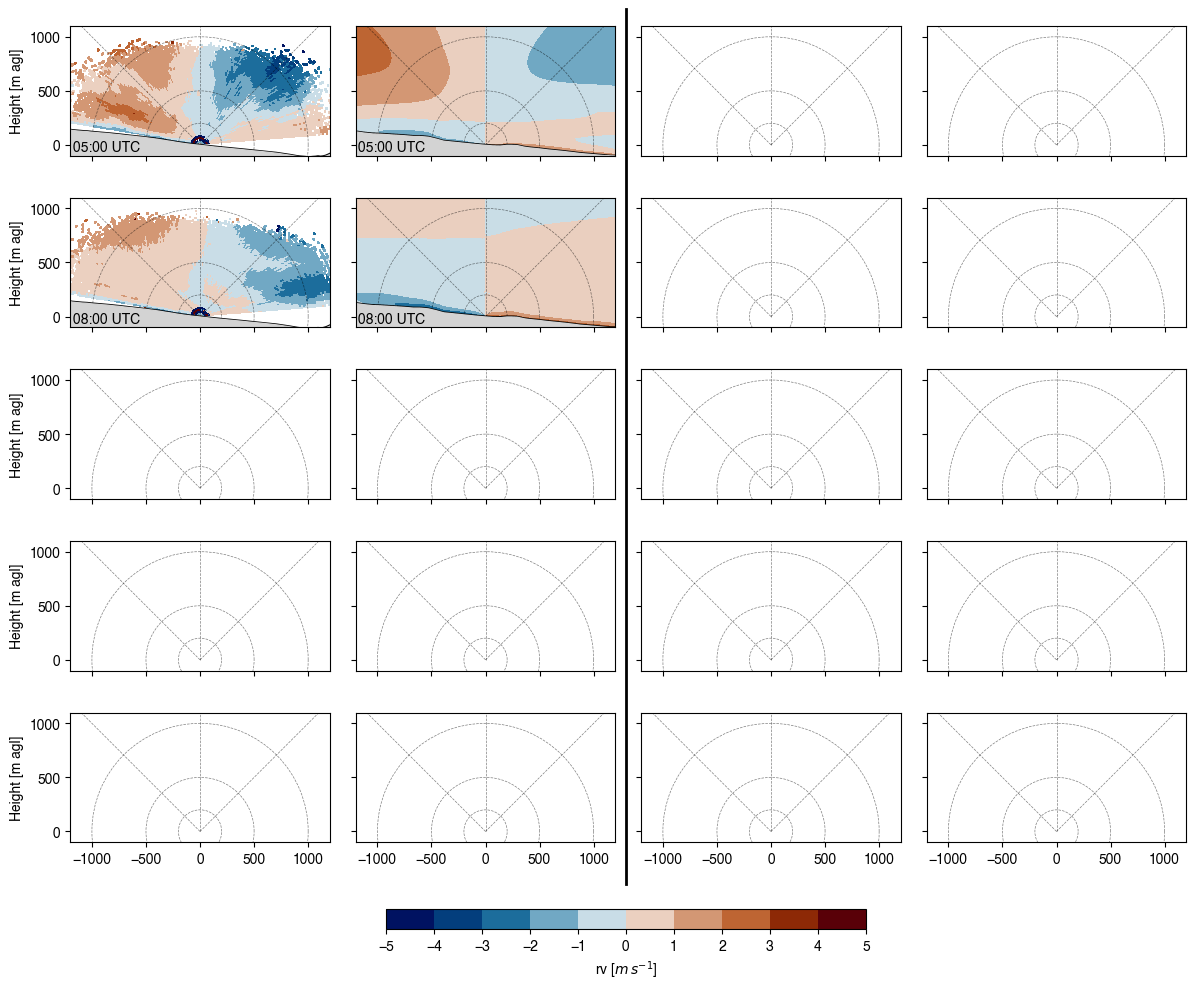

In [109]:
# discrete colormap
vmin, vmax = -5.0, 5.0 # boundary values for the rv colormap
rv_step = 1

bounds = np.arange(vmin, vmax+rv_step, rv_step)
cmap = plt.get_cmap(cm.vik)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)


fig, axes = plt.subplots(5, 4, figsize=(12,10), sharex=True, sharey=True)

row,col=0,0
for i, t in tqdm(enumerate(half_hours)):
    if i % 5 == 0 and i != 0:
        row = 0
        col += 2
    else:
        row = i % 5

    #--- 1. Prep work
    # get timestamps
    dt_rhi = pd.to_datetime(ds_rhi.half_hour.isel(half_hour=t).values)
    dt_icon = pd.to_datetime(ds_icon.time.isel(time=t).values)

    # get actual data (radial velocity
    dv_rhi  = ds_rhi.dv.isel(half_hour=t).values # open the RHI dataset at the respective index
    dv_icon = ds_icon.rv.isel(time=t).values

    # Get the cartesian coordinates for both plots
    x_rhi = ds_rhi.x.values
    z_rhi = ds_rhi.z.values

    #--- 2. RHI plot
    ax = axes[row, col]
    pcm25 = ax.pcolormesh(z_rhi, x_rhi, np.fliplr(dv_rhi.T),
                          shading="nearest", cmap=cmap, norm=norm)
    add_dt_text(ax, dt_rhi)
    add_dem(ax, dem_rhi)

    #--- 3. ICON plot
    #icon = np.ma.masked_invalid(dv_icon)
    ax = axes[row, col+1]
    ax.imshow(dv_icon, origin="lower", aspect="auto", interpolation="none", cmap=cmap, norm=norm, extent=icon_extent)
    add_dt_text(ax, dt_icon)
    add_dem(ax, dem_icon)

# limits and grid
for i,ax in enumerate(axes.flat):
    ax.set_xlim(-1200, 1200)
    ax.set_ylim(-100, zlim)
    ax.set_aspect("equal")
    add_range_semicircles_and_gridlines(ax, radii=[200, 500, 1000], zorder=8)
    for s in ax.spines.values(): s.set_zorder(50)   # subplot frame on top of DEM overlay
    if i % 4 == 0: ax.set_ylabel('Height [m agl]')

# colorbar
cax = fig.add_axes([0.313, 0.08, 0.4, 0.02])
fig.colorbar(pcm25, cax=cax, orientation="horizontal",
             boundaries=bounds, ticks=bounds,
             label=r"rv [$m\,s^{-1}$]")

# add vertical separator between 2nd and 3rd column
sep = Line2D([0.513, 0.513], [0.125, 1], transform=fig.transFigure, color='k', linewidth=2)
fig.add_artist(sep)

# final formatting
fig.subplots_adjust(left=0.05, right=0.98, top=1,
                    bottom=0.15, wspace=0.1, hspace=0.05)
#fig.savefig("HEFEX_III_Lidar_RHI_20250814.png", dpi=300)
# plt.tight_layout()
plt.show()

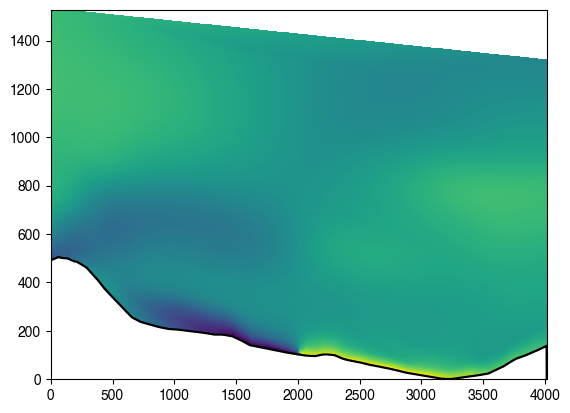

In [85]:
plt.imshow(dv_icon, origin="lower", aspect="auto", interpolation="none",)

mask = ~np.isnan(dv_icon)
idx = mask.argmax(axis=0)
idx



plt.plot(np.arange(len(idx)), idx, '-', color='k')

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(12,10), sharex=True, sharey=True)




    # Get the colormaps for the RHI and ICON (here ICON nans are topography so we set them to black)
    cmap_rhi = cmap.copy()
    cmap_rhi.set_bad("white")

    cmap_icon = cmap.copy()
    cmap_icon.set_bad("lightgrey")

    # Loop through the time indices wanted
    row,col=0,0
    for i, t in tqdm(enumerate(times)):
        if i % 5 == 0 and i != 0:
            row = 0
            col += 2
        else:
            row = i % 5

        dv_rhi_25 = ds_rhi_25.dv.isel(half_hour=t-1).values # open the RHI dataset at the respective index
        dv_icon_25 = ds_icon_25.rv.isel(time=t + delay).values # open the ICON dataset at the respective index plut delay if ICON started earlier

        dt_rhi = pd.to_datetime(ds_rhi_25.half_hour.isel(half_hour=t).values)
        dt_icon = pd.to_datetime(ds_icon_25.time.isel(time=t + delay).values)

        # Get the cartesian coordinates for both plots
        x_rhi_25 = ds_rhi_25_meta.x.values
        z_rhi_25 = ds_rhi_25_meta.z.values

        x_icon_25 = ds_icon_25.horizontal_dist.values
        z_icon_25 = ds_icon_25.height.values


        # ============================================================
        # 25 deg
        # ============================================================

        if match_x:
            extent25 = [-scan_length, scan_length, z_icon_25.min(), z_icon_25.max()]
        else:
            extent25 = [x_icon_25.min(), x_icon_25.max(), z_icon_25.min(), z_icon_25.max()]

        # RHI plot
        ax = axes[row, col]
        pcm25 = ax.pcolormesh(z_rhi_25, x_rhi_25, np.fliplr(dv_rhi_25.T), # The radial velocity field was stored upside down so we need to turn it
                                      shading="nearest", cmap=cmap_rhi, norm=norm)
        #ax.set_title(dt_rhi.strftime("%H:%M"))
        ax.text(0.01, 0.01, dt_rhi.strftime("%H:%M UTC"),
                transform=ax.transAxes,  # use axes coords (0–1)
                #bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=2),
                fontsize=10, ha="left", va="bottom", color="black", zorder=15)

        # If we provide DEM data we use this as topography mask else the topo from ICON
        if dem_paths is not None:
            m_along = dem_paths[0]
            Ny, Nx = np.fliplr(dv_rhi_25.T).shape
            xmin, xmax, ymin, ymax = extent25

            upsample = 6

            Ny_hr = Ny * upsample
            Nx_hr = Nx * upsample

            x_lr = np.linspace(0, 1, Nx)
            x_hr = np.linspace(0, 1, Nx_hr)

            dem_hr = np.interp(x_hr, x_lr, m_along)

            y_hr = np.linspace(ymin, ymax, Ny_hr)

            mask_hr = y_hr[:, None] < dem_hr[None, :]

            icon_overlay_25 = np.zeros(mask_hr.shape + (4,))
            icon_overlay_25[mask_hr] = [0, 0, 0, 1.0]
            icon_overlay_25[~mask_hr] = [0, 0, 0, 0.0]
            #ax.imshow(icon_overlay_25, origin="lower", extent=extent25, aspect="auto", zorder=10, cmap='Greys')

            y_floor = -1000
            x_dem = np.linspace(xmin, xmax, len(m_along))
            ax.fill_between(
                x_dem,
                y1=y_floor,
                y2=m_along,
                color="lightgrey",
                #alpha=0.2,
                zorder=9
            )
            ax.plot(x_dem, m_along, c='k')
            for s in ax.spines.values():
                s.set_zorder(50)

        else:
            icon_overlay_25 = np.zeros(dv_icon_25.shape + (4,))
            icon_mask_25 = np.isnan(dv_icon_25)
            icon_overlay_25[icon_mask_25] = [0, 0, 0, 1.0]
            icon_overlay_25[~icon_mask_25] = [0, 0, 0, 0.0]
            ax.imshow(icon_overlay_25, origin="lower", extent=extent25,
                              aspect="auto", zorder=10)

        # ICON panel
        icon25 = np.ma.masked_invalid(dv_icon_25)
        ax = axes[row, col+1]
        ax.imshow(icon25, origin="lower", aspect="auto", interpolation="none",
                          cmap=cmap_icon, norm=norm, extent=extent25)
        #ax.set_title(dt_icon.strftime("%H:%M"))
        ax.text(0.01, 0.01, dt_icon.strftime("%H:%M UTC"),
                transform=ax.transAxes,  # use axes coords (0–1)
                #bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=2),
                fontsize=10, ha="left", va="bottom", color="black", zorder=15)


    # ============================================================
    # Formatting
    # ============================================================

    for ax in axes.flat:
        ax.set_xlim(-1200, 1200)
        ax.set_ylim(-100, zlim)
        ax.set_aspect("equal")
        # Add the guiding lines
        add_range_semicircles_and_gridlines(
            ax,
            radii=[200, 500, 1000],
            edgecolor='black',
            zorder=8
        )

    # add vertical separator between 2nd and 3rd column
    sep = Line2D([0.513, 0.513], [0.125, 1], transform=fig.transFigure,
                       color='k', linewidth=2)
    fig.add_artist(sep)

    # One colorbar for all
    cax = fig.add_axes([0.313, 0.08, 0.4, 0.02])
    fig.colorbar(pcm25, cax=cax, orientation="horizontal",
                 boundaries=bounds, ticks=bounds,
                 #pad=0.04, fraction=0.1,
                 label="rv [$m\,s^{-1}$]")

    return fig